# LLM usage for baking: an evaluation of ratio-sensitive recipes
<!-- 2026-09-07 -->

## Background

Outside of work, one of my most frequent usages of LLMs is while I am cooking. I don't like to waste food, so I frequently have meals whose inspiration is "these cans are past their expiration date and I have carrots in the fridge that look questionable". I find that LLMs can usually give good suggestions in these situations, and I've talked to others with similar experiences.

However, given the adage that "cooking is an art, but baking is a science", I was curious about whether my LLM-assisted cooking could extend to recipes with tighter ingredient quantities. If I'm adding salt while cooking, I can taste halfway through so I don't put too much, but you can't do that when you're baking a pie crust or making bread. 

In this post I'm going to explore:
* Can you rely on ChatGPT to give you reliable quantities for baking?
* Does asking for a "foolproof" recipe increase ingredient quantity accuracy?
* If you are cooking for crowd, can you ask the LLM for a large quantity or should you ask for a normal quantity and scale up/down manually?

## Experimental setup

### Model selection

I used GPT 5-6 luna for this comparison. I did this for a few reasons: 
* I generated a couple of recipes using the ChatGPT app, and one of them used GPT 5-6 luna so I'm confident that some people are getting their recipes from GPT 5-6 Luna
* GPT 5-6 Luna is really cheap and I had some credits left in my OpenAI account
* I considered using Claude for this comparison, but when you use the Claude app to generate a recipe, it uses a tool to provide you with an interface. I felt that using GPT 5-6 Luna and scoring free-text would be a good analog to what users actually experience when they generate recipes.

### Food Selection

I chose recipes that had fairly tight tolerances on relative quantities between ingredients, because I wanted to identify clear "failures" when the LLM generated a recipe outside the bounds. 

I also chose recipes which would scale ingredients in a linear fashion. For example the yeast-to-flour ratio in a bread recipe is important, but when you double a bread recipe, you don't necessarily always have to double the yeast (at least biologically, my wife may contend that there were some occasions with slow-rising rolls where doubling the yeast may have been helpful).

Anyway, the foods I chose to use for this experiment were:
* Pie dough (with a sensitive fat:flour and water:flour ratio)
* Panna cotta (with a sensitive liquid:gelatin ratio)
* Pastry Cream (with a sensitive cornstarch:milk ratio)
* Choux pastry (with a sensitive egg:flour ratio)

### Recipe evaluation

To assign pass/fail results to a recipe, I extracted quantities into a structured format using a second LLM call, converted them to grams, and computed ratios observed in the recipe. 

To determine recipes with successful ratios, I looked at results for 5-10 actual tested recipes I found on the internet. However, for panna cotta, I found a [Seattle Times Article](https://www.seattletimes.com/life/food-drink/3-keys-to-perfect-panna-cotta/) where an author tested recipes and reported results so I used that one for the ranges. 

Here are the acceptable ranges I'm using in my analysis (note that Claude generated this table):

| Recipe | Ratio(s) checked | Ground truth | Basis |
|---|---|---|---|
| **Pie dough** | fat:flour (by weight) | pass: 0.68–0.89 | Convergence across 8 independently-tested recipes |
| | water:flour (by weight) | pass: 0.28–0.50 | Same 8-recipe set. Shortening-only recipe sets the high end (shortening carries no water, so more must be added vs. butter) |
| **Panna cotta** | gelatin:liquid (by weight %) | pass: 0.65%–3.9% | Documented range across tested/published recipes by Seattle Times (set/don't-set language).  |
| **Pastry cream** | cornstarch:milk (by weight %) | pass: 4.1%–8.3% | Convergence across 12 independently-tested recipes (King Arthur x2, Scotch & Scones, Sally's Baking Addiction, Allrecipes, Serious Eats, Preppy Kitchen, Martha Stewart, Stay at Home Chef, Natasha's Kitchen, Food Network, one additional source). Dense cluster ~4.8%–6.6%; King Arthur GF (4.1%) and Preppy Kitchen's richer 6-yolk version (8.3%) are the outer bounds. |
| **Choux pastry** | egg:flour (by weight) | pass: 1.3:1–2.3:1 | Convergence across 10 independently-tested recipes (Ruhlman canonical, America's Test Kitchen, Food Network, Sally's Baking Addiction, Allrecipes, Bonni Bakery, King Arthur, The Flavor Bender, The Buttery Crust, one additional source). King Arthur's tested recipe (1.33:1) sets the low end; Bonni Bakery's own stated 5–6 egg range (1.92:1–2.31:1) sets the high end. Egg weight assumed ~50g/large egg, no shell, unless a source states shell-inclusive weight (see caveat below). |

### Prompt 

I used a very simple prompt to generate recipes: 

```
Can you give me a recipe for [adjective] [requested food] [quantity modifier]?
```

In order to evaluate the effect of asking for a "foolproof" recipe, I changed `adjective` to be either "very tasty", "foolproof", or "avant garde".

I used the food I wante to generate in the place of `requested food` in the chunk above

For the `quantity modifier`, I used either no modifier, 6 people (to approcimate the most common usage) 35 people (to approximate the max of what a home cook might be cooking for) and 173 people (to evaluate LLM scaling in an out-of-distribution quantity).

I did not provide a system prompt. 



In [7]:
import pandas as pd

ip = get_ipython()
fmt = ip.display_formatter.formatters

# pandas exposes _repr_html_ rather than registering in type_printers, so
# deleting from type_printers is a no-op. Registering a printer that returns
# None is what actually suppresses the text/html mimetype.
fmt['text/html'].for_type(pd.DataFrame, lambda df: None)
fmt['text/html'].for_type(pd.Series, lambda s: None)

# Emit markdown instead, which nbconvert falls back to once html is gone.
fmt['text/markdown'].for_type(pd.DataFrame, lambda df: df.to_markdown())
fmt['text/markdown'].for_type(pd.Series, lambda s: s.to_markdown())

<function __main__.<lambda>(s)>

In [8]:
# --- One color scheme for the whole notebook. Every chart below imports from
# --- here rather than picking its own colors. ---
import matplotlib.pyplot as plt
import matplotlib as mpl

INK        = "#0b0b0b"   # titles, primary text
INK_MUTED  = "#52514e"   # axis labels, secondary text
GRID       = "#dcdbd6"   # gridlines, spines
BG         = "#fcfcfb"   # figure/axes background
BAND       = "#e7e6e2"   # shaded reference bands

# Categorical palette: one fixed color per adjective, used identically in
# every chart that breaks results out by adjective.
ADJ_COLOR = {"control": "#2a78d6", "foolproof": "#eb6834", "avant_garde": "#1baf7a"}
ADJ_MARKER = {"control": "o", "foolproof": "s", "avant_garde": "^"}
ADJ_LABEL = {"control": "really tasty (control)", "foolproof": "foolproof",
             "avant_garde": "avant garde"}

# Sequential palette (light -> dark) for the four recipes, used identically
# whenever recipes are broken out on one axis.
RECIPE_COLOR = {
    "pie_dough": "#8ab6e6",
    "panna_cotta": "#4f8fd6",
    "pastry_cream": "#2a5fa8",
    "choux": "#12305c",
}
RECIPE_LABEL = {"pie_dough": "pie dough", "panna_cotta": "panna cotta",
                 "pastry_cream": "pastry cream", "choux": "choux pastry"}

SCALE_LABEL = {"default": "unspecified", "6": "6", "35": "35", "173": "173"}

def style_axes(ax):
    ax.set_facecolor(BG)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=9, length=0)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def new_fig(figsize=(9, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(BG)
    style_axes(ax)
    return fig, ax

mpl.rcParams["font.size"] = 10
mpl.rcParams["text.color"] = INK
mpl.rcParams["axes.labelcolor"] = INK_MUTED

In [14]:
import json
from pathlib import Path

import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint

DATA_ROOT = Path("recipe_generation")

RECIPE_NAMES = ["pie_dough", "panna_cotta", "pastry_cream", "choux"]
ADJECTIVE_NAMES = ["control", "foolproof", "avant_garde"]
SCALE_NAMES = ["default", "6", "35", "173"]
SCALE_N = {"default": np.nan, "6": 6, "35": 35, "173": 173}

scores = pd.read_csv(DATA_ROOT / "results" / "scores.csv")
scores["abs_log2_deviation"] = scores["log2_deviation"].abs()
scores["adjective"] = pd.Categorical(scores["adjective"], ADJECTIVE_NAMES, ordered=True)
scores["scale"] = pd.Categorical(scores["scale"], SCALE_NAMES, ordered=True)
scores["recipe"] = pd.Categorical(scores["recipe"], RECIPE_NAMES, ordered=True)

per_gen = pd.read_csv(DATA_ROOT / "results" / "per_generation.csv")
per_gen["adjective"] = pd.Categorical(per_gen["adjective"], ADJECTIVE_NAMES, ordered=True)
per_gen["scale"] = pd.Categorical(per_gen["scale"], SCALE_NAMES, ordered=True)
per_gen["recipe"] = pd.Categorical(per_gen["recipe"], RECIPE_NAMES, ordered=True)


### Example Generation

Here's an example of one of the recipes generated, how ingredients were extracted, and results.



In [15]:
def _condition_dir(recipe, adjective, scale):
    return DATA_ROOT / "data" / f"{recipe}__{adjective}__{scale}"

def _read_manifest(cdir):
    import csv
    with open(cdir / "manifest.csv", newline="") as f:
        return {int(row["repeat_index"]): row for row in csv.DictReader(f)}

def show_example(recipe="choux", adjective="avant_garde", scale="173", repeat_index=0):
    '''Print the prompt, full generated recipe, extracted ingredient table,
    and final ratio score for one (recipe, adjective, scale, repeat) cell.

    Example: show_example("pie_dough", "foolproof", "35", repeat_index=2)
    '''
    cdir = _condition_dir(recipe, adjective, scale)
    manifest = _read_manifest(cdir)
    if repeat_index not in manifest:
        raise KeyError(f"no repeat {repeat_index} in {cdir.name}; have {sorted(manifest)}")
    h = manifest[repeat_index]["hash"]

    gen = json.loads((cdir / f"{h}.generation.json").read_text())
    extraction = json.loads((cdir / f"{h}.extraction.json").read_text())
    score = json.loads((cdir / f"{h}.score.json").read_text())

    print("=" * 78)
    print(f"CONDITION   {RECIPE_LABEL[recipe]} | {ADJ_LABEL[adjective]} | "
          f"serving size: {SCALE_LABEL[scale]} | repeat {repeat_index}")
    print(f"PROMPT      {gen['prompt']!r}")
    print("=" * 78)

    print("\n--- 1. Generated recipe (verbatim model response) ---\n")
    print(gen["response_text"])

    print("\n--- 2. Extracted ingredient lines (first three) ---\n")
    ing = pd.DataFrame(extraction["extraction"]["ingredients"]).head(3)
    cols = ["name", "quantity", "quantity_low", "quantity_high", "unit",
            "component", "is_core", "option_group", "is_default_option"]
    display(ing[[c for c in cols if c in ing.columns]])

    print("\n--- 3. Scored ratio(s) ---\n")
    for ratio_name, r in score["ratios"].items():
        unit = "%" if r["as_percent"] else ""
        verdict = "PASS" if r["passed"] else "FAIL"
        print(f"  {ratio_name}: {r['numerator']} / {r['denominator']} = "
              f"{r['value']:.4g}{unit}  "
              f"(band {r['band_low']}-{r['band_high']}{unit}, "
              f"center {r['band_center']}{unit})  -> {verdict}")
    print(f"\n  recipe-level verdict: {'PASS' if score['passed'] else 'FAIL'}")


show_example("choux", "avant_garde", "173", repeat_index=1)

CONDITION   choux pastry | avant garde | serving size: 173 | repeat 1
PROMPT      'Can you give me a recipe for avant garde choux pastry for 173 people?'

--- 1. Generated recipe (verbatim model response) ---

## Avant-garde yuzu, black-sesame and vanilla choux  
**Yield:** approximately 200 filled choux, enough for 173 guests with extras  
**Serving assumption:** 1 choux per person. For 2 each, double the quantities.

Use metric weights for consistency. This is a large production, so bake the choux in several batches.

---

## 1. Black-sesame craquelin

### Ingredients
- 300 g unsalted butter, softened  
- 280 g light brown sugar  
- 250 g plain flour  
- 50 g finely ground black sesame  
- 4 g fine salt  

### Method
1. Beat the butter and sugar until smooth.
2. Mix in the flour, sesame and salt just until combined.
3. Roll between sheets of parchment to approximately **2 mm thick**.
4. Chill or freeze until firm.
5. Cut approximately **200 discs**, 4–5 cm in diameter.

Keep the disc

|    | name              |   quantity |   quantity_low |   quantity_high | unit   | component              | is_core   | option_group   | is_default_option   |
|---:|:------------------|-----------:|---------------:|----------------:|:-------|:-----------------------|:----------|:---------------|:--------------------|
|  0 | unsalted butter   |        300 |            nan |             nan | g      | black-sesame craquelin | False     |                | False               |
|  1 | light brown sugar |        280 |            nan |             nan | g      | black-sesame craquelin | False     |                | False               |
|  2 | plain flour       |        250 |            nan |             nan | g      | black-sesame craquelin | False     |                | False               |


--- 3. Scored ratio(s) ---

  egg_to_flour: egg / flour = 1.438  (band 1.3-2.3, center 1.7999999999999998)  -> PASS

  recipe-level verdict: PASS


## Can you rely on ChatGPT to give you reliable quantities for baking?

ChatGPT produced recipes with ingredient ratios outside of the acceptable tolerances 24% of the time. Although my baking failures are more frequently of the "forgot to set a timer and now the fire alarm is going off" variety rather than "too much fat content in my dough" variety, it still seems like using an LLM for baking might be too risky. 

Note that some recipes had higher failure rates than others. This may be because some recipes are more forgiving than others, and it may also be because the distribution of recipes seen in training data was a differennt style of cooking than the recipes online currently. 


In [20]:
scores["recipe_ratio"] = scores["recipe"].astype(str) + " / " + scores["ratio"]

rp = per_gen[per_gen["recipe_passed"].notna()].copy()
rp["recipe_passed_int"] = rp["recipe_passed"].astype(int)

fail = (
    rp.groupby("recipe", observed=True)["recipe_passed_int"]
    .agg(n="size", n_pass="sum")
    .reset_index()
)
fail["n_fail"] = fail["n"] - fail["n_pass"]

fail = fail.set_index("recipe").loc[RECIPE_NAMES].reset_index()
fail["fail_rate"] = fail["n_fail"] / fail["n"]
ci = fail.apply(lambda r: proportion_confint(r["n_fail"], r["n"], method="wilson"), axis=1)
fail["ci_low"], fail["ci_high"] = zip(*ci)
df_to_print = fail.loc[:, ["recipe", "n", "fail_rate"]].rename({"recipe": "Recipe", "n": "Number Generated and Parsed", 
                                "fail_rate": "% failures"}, axis = 1)
df_to_print["Recipe"] = df_to_print["Recipe"].apply(lambda x: x.replace("_", " ").title())
display(df_to_print)

        

|    | Recipe       |   Number Generated and Parsed |   % failures |
|---:|:-------------|------------------------------:|-------------:|
|  0 | Pie Dough    |                            59 |    0.423729  |
|  1 | Panna Cotta  |                            59 |    0.0847458 |
|  2 | Pastry Cream |                            60 |    0         |
|  3 | Choux        |                            60 |    0.433333  |

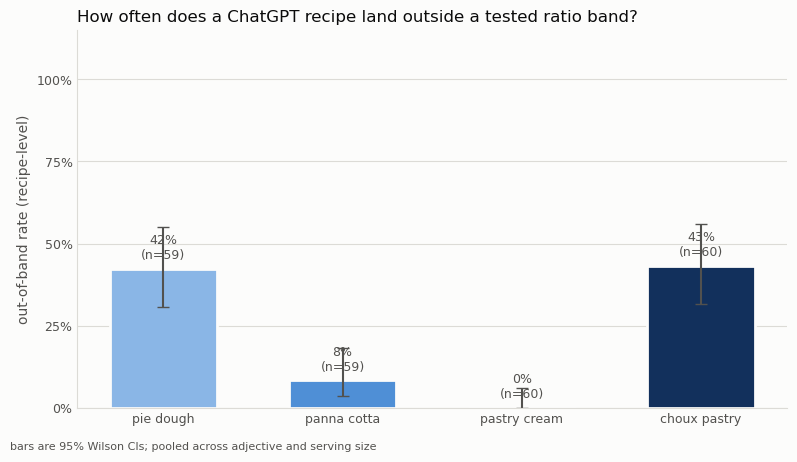

In [17]:


fig, ax = new_fig((8, 4.6))
x = range(len(RECIPE_NAMES))
bars = ax.bar(
    x, fail["fail_rate"],
    color=[RECIPE_COLOR[r] for r in RECIPE_NAMES],
    width=0.6, edgecolor=BG, linewidth=2,
    yerr=[fail["fail_rate"] - fail["ci_low"], fail["ci_high"] - fail["fail_rate"]],
    ecolor=INK_MUTED, capsize=4,
)
for i, row in fail.iterrows():
    ax.text(i, row["fail_rate"] + 0.03, f"{row['fail_rate']:.0%}\n(n={row['n']})",
            ha="center", fontsize=9, color=INK_MUTED)
ax.set_xticks(list(x))
ax.set_xticklabels([RECIPE_LABEL[r] for r in RECIPE_NAMES])
ax.set_ylim(0, 1.15)
ax.set_yticks([0, .25, .5, .75, 1.0]); ax.set_yticklabels(["0%","25%","50%","75%","100%"])
ax.set_ylabel("out-of-band rate (recipe-level)")
ax.set_title("How often does a ChatGPT recipe land outside a tested ratio band?",
             color=INK, fontsize=12, loc="left")
fig.text(0.01, 0.01, "bars are 95% Wilson CIs; pooled across adjective and serving size",
          color=INK_MUTED, fontsize=8)
fig.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## Does asking for a "foolproof" recipe increase ingredient quantity accuracy?

No, it doesn't look like asking for a "foolproof" recipe reduces out-of-band ratio occurrence. It may be that more rigorous prompting, extended reasoning, or tool use can reduce out-of-band occurrence, but I didn't test those because they didn't seem applicable to the average baker trying to get the most out of ChatGPT.

In [23]:
by_adj = (
    rp.groupby(["recipe", "adjective"], observed=True)
    .agg(n=("recipe_passed_int", "size"),
         fail_rate=("recipe_passed_int", lambda s: 1 - s.mean()),
         mean_abs_dev=("mean_abs_dev", "mean"))
    .reset_index()
)


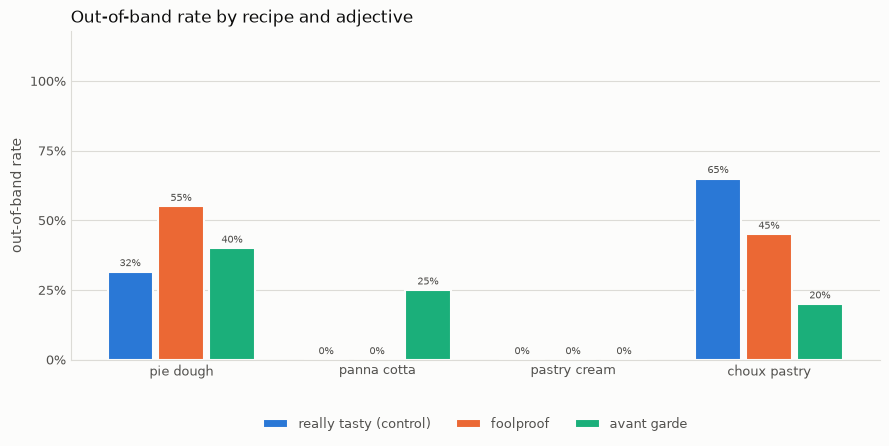

In [9]:
fig, ax = new_fig((9, 4.6))
width = 0.26
x = range(len(RECIPE_NAMES))
for offset, adj in zip((-width, 0, width), ADJECTIVE_NAMES):
    rates = [by_adj.query("recipe == @r and adjective == @adj")["fail_rate"].pipe(
                lambda s: s.iloc[0] if len(s) else float("nan")) for r in RECIPE_NAMES]
    pos = [i + offset for i in x]
    bars = ax.bar(pos, rates, width * 0.9, color=ADJ_COLOR[adj], label=ADJ_LABEL[adj],
                  edgecolor=BG, linewidth=1.5)
    for b, rate in zip(bars, rates):
        if rate == rate:
            ax.text(b.get_x() + b.get_width() / 2, rate + 0.02, f"{rate:.0%}",
                    ha="center", fontsize=7.5, color=INK_MUTED)
ax.set_xticks(list(x)); ax.set_xticklabels([RECIPE_LABEL[r] for r in RECIPE_NAMES])
ax.set_ylim(0, 1.18); ax.set_yticks([0, .25, .5, .75, 1.0])
ax.set_yticklabels(["0%","25%","50%","75%","100%"])
ax.set_ylabel("out-of-band rate")
ax.set_title('Out-of-band rate by recipe and adjective', color=INK, fontsize=12, loc="left")
ax.legend(frameon=False, fontsize=9, labelcolor=INK_MUTED, ncol=3,
          loc="upper center", bbox_to_anchor=(0.5, -0.14))
fig.tight_layout()
plt.show()

In [10]:
# Statistical model: continuous deviation is the primary outcome (pass/fail
# saturates at 0%/100% for two recipes and has little variance left to
# explain). OLS on |log2 deviation| with recipe fixed effects isolates the
# adjective's own effect from the ratio's baseline strictness.
adj_model = smf.ols("mean_abs_dev ~ C(recipe) + C(adjective)", data=rp).fit()
print(adj_model.summary())

                            OLS Regression Results                            
Dep. Variable:           mean_abs_dev   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     199.9
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           5.77e-82
Time:                        11:24:50   Log-Likelihood:                 58.864
No. Observations:                 238   AIC:                            -105.7
Df Residuals:                     232   BIC:                            -84.89
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

## If you are cooking for crowd, can you ask the LLM for a large quantity or should you ask for a normal quantity and scale up/down manually?

### Are ratios self-consistent at low or large serving sizes? 

In [33]:
scaled = scores[scores["value"].notna() & scores["scale_n"].notna()].copy()
scaled["log10_people"] = np.log10(scaled["scale_n"])

trend_model = smf.ols("abs_log2_deviation ~ log10_people * C(recipe_ratio)", data=scaled).fit()

# Pull out one slope (deviation added per tenfold increase in people) per
# recipe/ratio from the interaction model, rather than fitting each group
# separately -- this borrows strength across groups for the standard errors.
base_ratio = sorted(scaled["recipe_ratio"].unique())[0]
rows = []
for rr in sorted(scaled["recipe_ratio"].unique()):
    if rr == base_ratio:
        slope = trend_model.params["log10_people"]
        se = trend_model.bse["log10_people"]
    else:
        name = f"log10_people:C(recipe_ratio)[T.{rr}]"
        slope = trend_model.params["log10_people"] + trend_model.params[name]
        se = np.sqrt(
            trend_model.cov_params().loc["log10_people", "log10_people"]
            + trend_model.cov_params().loc[name, name]
            + 2 * trend_model.cov_params().loc["log10_people", name]
        )
    rows.append({"recipe_ratio": rr, "n": (scaled["recipe_ratio"] == rr).sum(),
                 "slope_per_decade": slope, "se": se,
                 "ci_low": slope - 1.96 * se, "ci_high": slope + 1.96 * se})
trend = pd.DataFrame(rows)
trend["crosses_zero"] = (trend["ci_low"] < 0) & (trend["ci_high"] > 0)


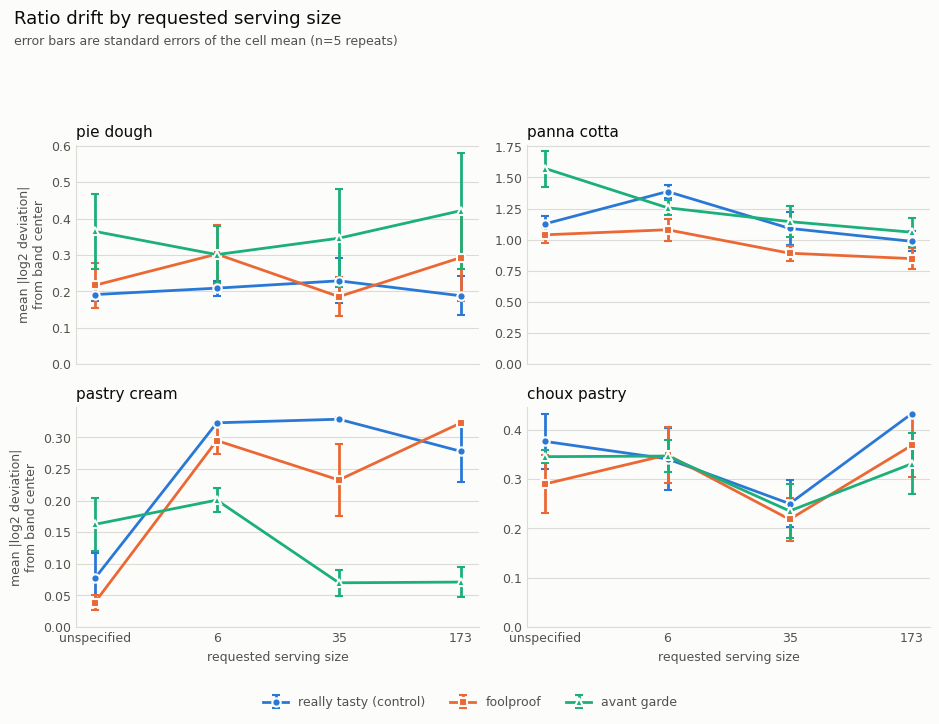

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 7), sharex=True)
fig.patch.set_facecolor(BG)
scored_all = scores[scores["value"].notna()]
for ax, recipe in zip(axes.flat, RECIPE_NAMES):
    style_axes(ax)
    subset = scored_all[scored_all["recipe"] == recipe]
    for adj in ADJECTIVE_NAMES:
        cells_ = subset[subset["adjective"] == adj].groupby("scale", observed=False)["abs_log2_deviation"]
        means = cells_.mean().reindex(SCALE_NAMES)
        sems = cells_.sem().reindex(SCALE_NAMES)
        xpos = range(len(SCALE_NAMES))
        ax.errorbar(xpos, means.values, yerr=sems.values, color=ADJ_COLOR[adj],
                    marker=ADJ_MARKER[adj], markersize=6, linewidth=2,
                    markeredgecolor=BG, markeredgewidth=1.5, capsize=3,
                    label=ADJ_LABEL[adj])
    ax.set_title(RECIPE_LABEL[recipe], color=INK, fontsize=11, loc="left")
    ax.set_xticks(list(range(len(SCALE_NAMES))))
    ax.set_xticklabels([SCALE_LABEL[s] for s in SCALE_NAMES])
    ax.set_ylim(bottom=0)
for ax in axes[:, 0]:
    ax.set_ylabel("mean |log2 deviation|\nfrom band center", fontsize=9)
for ax in axes[-1]:
    ax.set_xlabel("requested serving size", fontsize=9)
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, fontsize=9,
           labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Ratio drift by requested serving size", color=INK, fontsize=13, x=0.02, y=0.995, ha="left")
fig.text(0.02, 0.945, "error bars are standard errors of the cell mean (n=5 repeats)",
         color=INK_MUTED, fontsize=9, ha="left")
fig.tight_layout(rect=(0, 0.04, 1, 0.90))
plt.show()

In [32]:
cell_sd = (
    scored_all.groupby(["recipe", "ratio", "adjective", "scale"], observed=True)
    ["log2_deviation"].agg(sd="std", n="count").reset_index()
)
cell_sd["scale_n"] = cell_sd["scale"].map(SCALE_N)
cell_sd_numeric = cell_sd[cell_sd["scale"] != "default"].dropna(subset=["sd"]).copy()
cell_sd_numeric["log10_scale_n"] = np.log10(cell_sd_numeric["scale_n"])

noise_model = smf.ols("sd ~ log10_scale_n * C(recipe)", data=cell_sd_numeric).fit()
print(noise_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     sd   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     3.062
Date:                Mon, 07 Sep 2026   Prob (F-statistic):             0.0120
Time:                        13:56:20   Log-Likelihood:                 29.346
No. Observations:                  45   AIC:                            -42.69
Df Residuals:                      37   BIC:                            -28.24
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

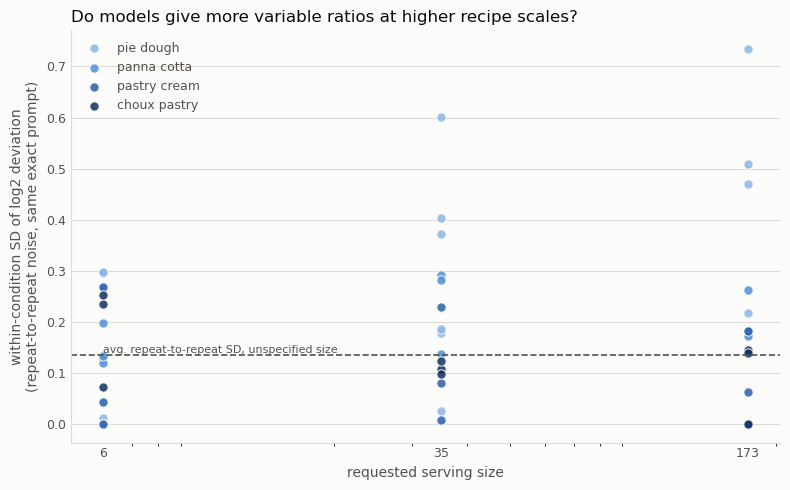

In [30]:
fig, ax = new_fig((8, 5))
for recipe in RECIPE_NAMES:
    sub = cell_sd_numeric[cell_sd_numeric["recipe"] == recipe]
    if sub.empty:
        continue
    ax.scatter(sub["scale_n"], sub["sd"], color=RECIPE_COLOR[recipe],
              s=45, alpha=0.85, label=RECIPE_LABEL[recipe],
              edgecolor=BG, linewidth=0.8)
default_sd = cell_sd[cell_sd["scale"] == "default"]["sd"].dropna()
if len(default_sd):
    ax.axhline(default_sd.mean(), color=INK_MUTED, linestyle="--", linewidth=1.2)
    ax.text(6, default_sd.mean() + 0.005,
            "avg. repeat-to-repeat SD, unspecified size", color=INK_MUTED, fontsize=8)
ax.set_xscale("log")
ax.set_xticks([6, 35, 173]); ax.set_xticklabels(["6", "35", "173"])
ax.set_xlabel("requested serving size")
ax.set_ylabel("within-condition SD of log2 deviation\n(repeat-to-repeat noise, same exact prompt)")
ax.set_title("Do models give more variable ratios at higher recipe scales?",
             color=INK, fontsize=12, loc="left")
ax.legend(frameon=False, fontsize=9, labelcolor=INK_MUTED, loc="upper left")
fig.tight_layout()
plt.show()

## Is ChatGPT consistent from generation to generation?

Every condition in this study was run 5 times at the identical prompt --
same recipe, same adjective, same serving size, same temperature and
defaults, no seed. That gives a direct way to separate "how much does the
ratio move because I changed the prompt" from "how much does it move for no
reason at all."

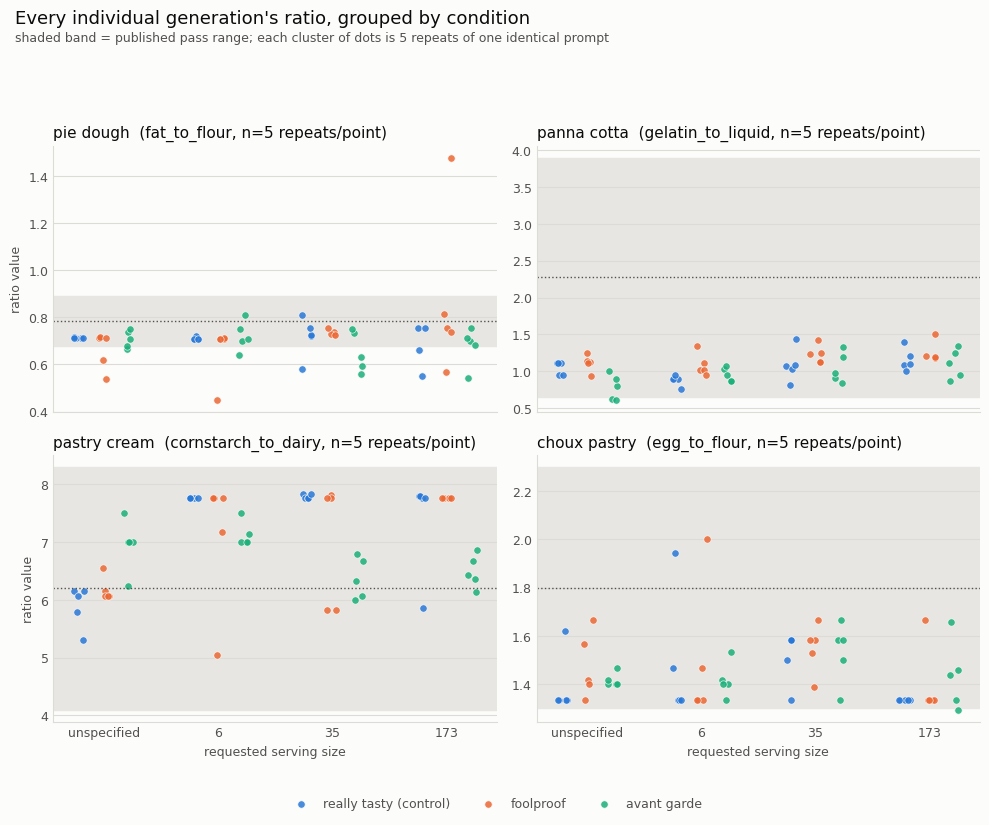

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
fig.patch.set_facecolor(BG)
dodge = {"control": -0.22, "foolproof": 0.0, "avant_garde": 0.22}
rng = np.random.default_rng(0)

for ax, recipe in zip(axes.flat, RECIPE_NAMES):
    style_axes(ax)
    sub = scores[(scores["recipe"] == recipe) & scores["value"].notna()]
    # Pick the ratio with the most scored rows if a recipe has more than one.
    main_ratio = sub["ratio"].value_counts().idxmax()
    sub = sub[sub["ratio"] == main_ratio]
    band_low = sub["band_low"].iloc[0]
    band_high = sub["band_high"].iloc[0]
    as_pct = 100 if (sub["outside_band_by"].abs().max() < 1 and band_high < 1) else 1
    ax.axhspan(band_low, band_high, color=BAND, zorder=0)
    ax.axhline((band_low + band_high) / 2, color=INK_MUTED, linewidth=1, linestyle=":")
    for adj in ADJECTIVE_NAMES:
        for si, scale in enumerate(SCALE_NAMES):
            vals = sub[(sub["adjective"] == adj) & (sub["scale"] == scale)]["value"]
            if vals.empty:
                continue
            jitter = rng.uniform(-0.05, 0.05, size=len(vals))
            ax.scatter(np.full(len(vals), si) + dodge[adj] + jitter, vals,
                      color=ADJ_COLOR[adj], s=28, alpha=0.85,
                      edgecolor=BG, linewidth=0.5,
                      label=ADJ_LABEL[adj] if si == 0 else None)
    ax.set_title(f"{RECIPE_LABEL[recipe]}  ({main_ratio}, n=5 repeats/point)",
                color=INK, fontsize=11, loc="left")
    ax.set_xticks(range(len(SCALE_NAMES)))
    ax.set_xticklabels([SCALE_LABEL[s] for s in SCALE_NAMES])
for ax in axes[:, 0]:
    ax.set_ylabel("ratio value", fontsize=9)
for ax in axes[-1]:
    ax.set_xlabel("requested serving size", fontsize=9)
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, fontsize=9,
           labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Every individual generation's ratio, grouped by condition",
             color=INK, fontsize=13, x=0.02, y=0.995, ha="left")
fig.text(0.02, 0.955, "shaded band = published pass range; each cluster of dots is 5 repeats of one identical prompt",
         color=INK_MUTED, fontsize=9, ha="left")
fig.tight_layout(rect=(0, 0.04, 1, 0.91))
plt.show()

In [16]:
# Statistical model: how much of the total variance in |log2 deviation| is
# explained by the factors we manipulated (recipe/ratio, adjective, scale),
# versus left over as pure repeat-to-repeat noise at an identical prompt?
scored_all = scores[scores["value"].notna()].copy()
variance_model = smf.ols(
    "abs_log2_deviation ~ C(recipe_ratio) + C(adjective) + C(scale)",
    data=scored_all,
).fit()

r2 = variance_model.rsquared
print(f"R-squared: {r2:.3f}")
print(f"Explained by recipe/ratio + adjective + scale: {r2:.0%}")
print(f"Left over as generation-to-generation noise at a fixed prompt: {1 - r2:.0%}")
print()
print(variance_model.summary())

R-squared: 0.743
Explained by recipe/ratio + adjective + scale: 74%
Left over as generation-to-generation noise at a fixed prompt: 26%

                            OLS Regression Results                            
Dep. Variable:     abs_log2_deviation   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     92.03
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           2.92e-79
Time:                        11:24:53   Log-Likelihood:                 37.968
No. Observations:                 297   AIC:                            -55.94
Df Residuals:                     287   BIC:                            -19.00
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                            coef    std er